# Gate12C-2 v2 statistical adequacy audit

**Epistemic status:** post-locked development audit. The historical `RETIRE_OR_DEMOTE` decision is unchanged.


## tl;dr

The retained 2,880-shard suite points primarily to insufficient finite-draw precision, not to an anomalous donor-collision process or a measured S0 spectral-geometry driver. This does **not** establish that N1 is an adequate real-data null: raw frames/principal angles were not persisted and no geometry-equivalence margin was frozen. The original locked failure remains a failure.


In [1]:
from pathlib import Path
import hashlib
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

AUDIT_ROOT = Path(os.environ['GATE12C2_AUDIT_ROOT'])
LOCKED_ROOT = Path(os.environ['GATE12C2_LOCKED_ROOT'])
assert AUDIT_ROOT.is_dir() and LOCKED_ROOT.is_dir()
pd.set_option('display.max_columns', 30)


## Context & methods

The audit independently reloads the retained CSV surfaces after the primary audit verified every manifest-bound locked file. It reconstructs the frozen 9-to-15 result, compares nested and disjoint draw subsets, uses a draw-block bootstrap that shares sampled draw indices across all 12 graphs, calibrates tail screens against fixed Gaussian samples of size 15, and reports dataset-level summaries over 48 independent synthetic datasets. Geometry diagnostics use persisted edge and product spectra only.


In [2]:
summary = json.loads((AUDIT_ROOT / 'audit_summary.json').read_text(encoding='utf-8'))
locked = json.loads((LOCKED_ROOT / 'analysis.json').read_text(encoding='utf-8'))
analysis_sha = hashlib.sha256((LOCKED_ROOT / 'analysis.json').read_bytes()).hexdigest()
assert summary['historical_locked_decision_unchanged'] is True
assert summary['source']['analysis_sha256'] == analysis_sha
assert locked['decision'] == 'RETIRE_OR_DEMOTE' and locked['locked_pass'] is False
summary['source']


{'analysis_sha256': '15ca5bd45d3aaf79f41464ff6c8ff0bd7a555a4897b07e7ea3ec0e4bf2caea49',
 'locked_decision': 'RETIRE_OR_DEMOTE',
 'locked_stability': {'comparison_count': 3456,
  'decision_agreement': 0.9612268518518519,
  'max_effect_shift': 0.7920492302837987,
  'p95_effect_shift': 0.30618430349705883},
 'manifest_file_count': 2882,
 'manifest_sha256': 'de439fb4b92db1618f7a9c96383e2012b0fb3d3b47b06c9d9100474c3b4b7f8c',
 'source_root': '<retained-locked-result-directory>',
 'study_sha256': 'f8586e10fece74472a7d327f6fd13a9ed0b6d813c5582873443bf01936e00262'}

## Data

The main endpoint table has 5,760 rows: five configurations × 48 datasets × 12 cases × two q values. The frozen stability comparison uses the 3,456 rows from S0, S1_PRIMARY, and S2.


In [3]:
endpoints = pd.read_csv(AUDIT_ROOT / 'endpoint_audit.csv')
endpoint_summary = pd.read_csv(AUDIT_ROOT / 'endpoint_summary.csv')
convergence = pd.read_csv(AUDIT_ROOT / 'convergence_summary.csv')
drivers = pd.read_csv(AUDIT_ROOT / 'driver_correlations.csv')
geometry = pd.read_csv(AUDIT_ROOT / 'pooled_geometry_summary.csv')
donors = pd.read_csv(AUDIT_ROOT / 'donor_summary.csv')
datasets = pd.read_csv(AUDIT_ROOT / 'dataset_level_summary.csv')
components = pd.read_csv(AUDIT_ROOT / 'component_summary.csv')
assert len(endpoints) == 5760
diagnostic = endpoints[endpoints['config'].isin(['S0', 'S1_PRIMARY', 'S2'])].copy()
assert len(diagnostic) == 3456


## Results — finite-draw precision

The exact locked p95 is reproduced. The disjoint and odd/even contrasts are larger than the nested 9-to-15 contrast, and 96.27% of nested shifts lie within 1.96 estimated k=15 Monte Carlo standard errors. Yet only 65.91% of endpoints have a 1.96-MCSE band no wider than the old 0.30 tolerance, showing that 15 draws do not deliver that precision uniformly.


In [4]:
locked_p95 = float(diagnostic['absolute_shift_9_to_15'].quantile(0.95))
assert abs(locked_p95 - locked['stability']['p95_effect_shift']) <= 1e-15
mc_summary = pd.Series({
    'locked_p95_9_to_15': locked_p95,
    'p95_prefix9_vs_suffix6': diagnostic['absolute_prefix9_suffix6'].quantile(0.95),
    'p95_odd_vs_even': diagnostic['absolute_odd_even'].quantile(0.95),
    'median_mcse_k15': diagnostic['mcse_k15'].median(),
    'p95_mcse_k15': diagnostic['mcse_k15'].quantile(0.95),
    'fraction_shift_within_1.96_mcse': (diagnostic['shift_over_mcse_k15'] <= 1.96).mean(),
    'fraction_1.96_mcse_within_0.30': (1.96 * diagnostic['mcse_k15'] <= 0.30).mean(),
    'spearman_shift_vs_mcse': diagnostic[['absolute_shift_9_to_15', 'mcse_k15']].corr(method='spearman').iloc[0, 1],
})
mc_summary.to_frame('value')


,value
locked_p95_9_to_15,0.306184
p95_prefix9_vs_suffix6,0.509666
p95_odd_vs_even,0.512352
median_mcse_k15,0.130223
p95_mcse_k15,0.245740
fraction_shift_within_1.96_mcse,0.962674
fraction_1.96_mcse_within_0.30,0.659144
spearman_shift_vs_mcse,0.384174


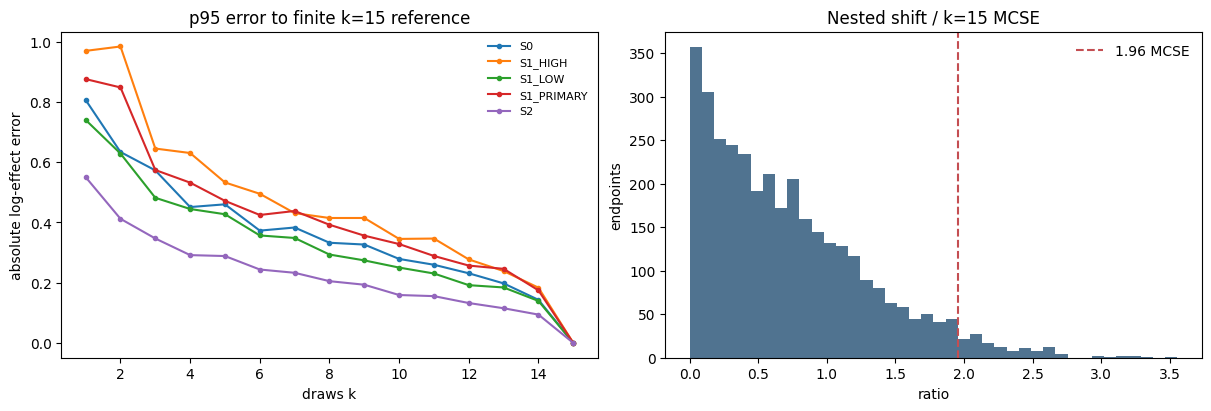

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for config, rows in convergence.groupby('config'):
    axes[0].plot(rows['k'], rows['p95_absolute_error'], marker='o', ms=3, label=config)
axes[0].set(title='p95 error to finite k=15 reference', xlabel='draws k', ylabel='absolute log-effect error')
axes[0].legend(frameon=False, fontsize=8)
axes[1].hist(diagnostic['shift_over_mcse_k15'], bins=40, color='#315A7D', alpha=.85)
axes[1].axvline(1.96, color='#C44E52', linestyle='--', label='1.96 MCSE')
axes[1].set(title='Nested shift / k=15 MCSE', xlabel='ratio', ylabel='endpoints')
axes[1].legend(frameon=False);


## Results — donor process and spectral geometry

Observed pair/triple collision and repeated-tuple rates match the exact independent-uniform expectations. Exposure imbalance is also close to the multinomial approximation, so there is no collision anomaly; there is ordinary sparse random coverage. On S0, pooled edge/product marginal discrepancies are modest, and within-S0 correlations between endpoint shift and measured geometry are near zero. However, the audit has no frozen geometry-equivalence margin and cannot reconstruct raw frame/principal-angle structure.


In [6]:
donor_view = donors[[
    'config', 'pair_collision_rate', 'independent_pair_collision_expectation',
    'triple_collision_rate', 'independent_triple_collision_expectation',
    'mean_repeated_tuple_rate', 'independent_repeated_tuple_rate_expectation',
    'mean_exposure_cv', 'multinomial_exposure_cv_approximation',
]]
s0_geometry = geometry.query("config == 'S0'")
s0_drivers = drivers.query("config == 'S0'").sort_values('spearman_rho', key=abs, ascending=False)
display(donor_view)
display(s0_geometry)
display(s0_drivers[['predictor', 'spearman_rho']])


,config,pair_collision_rate,independent_pair_collision_expectation,triple_collision_rate,independent_triple_collision_expectation,mean_repeated_tuple_rate,independent_repeated_tuple_rate_expectation,mean_exposure_cv,multinomial_exposure_cv_approximation
0,S0,0.253337,0.256198,0.008295,0.008264,0.005237,0.005242,0.798470,0.816497
1,S1_HIGH,0.257166,0.256198,0.008179,0.008264,0.005314,0.005242,0.798390,0.816497
2,S1_LOW,0.257166,0.256198,0.008179,0.008264,0.005314,0.005242,0.798390,0.816497
3,S1_PRIMARY,0.257166,0.256198,0.008179,0.008264,0.005314,0.005242,0.798390,0.816497
4,S2,0.255874,0.256198,0.008131,0.008264,0.005189,0.005242,0.799003,0.816497


,config,surface,case_count,max_quantile_difference,median_quantile_difference,max_ks,median_ks,median_cross_feature_correlation_max_difference,max_cross_feature_correlation_max_difference,max_cross_feature_correlation_bootstrap_upper
0,S0,edge,12,0.032958,0.012230,0.06169,0.033102,0.111866,0.154325,0.225693
1,S0,product,12,0.023254,0.010931,0.06169,0.036921,0.073155,0.109910,0.208434


,predictor,spearman_rho
9,mcse_k15,0.286857
8,bimodality_bic_delta,0.037244
2,cross_edge_correlation_max_difference,0.035334
0,edge_quantile_max_difference,0.032475
1,product_quantile_max_difference,0.022789
6,draw_excess_kurtosis,-0.017935
7,draw_max_robust_z,-0.016626
4,mean_exposure_cv,0.013421
5,max_exposure_range,0.006173
3,pair_collision_rate,0.005353


## Results — independent-dataset grain and components

Across 48 independent synthetic datasets, S0 remains centered near zero, S1_PRIMARY is strongly negative, and S2 is positive. This supports directional synthetic separation, not a new promotion decision. Component shifts occur across tail, propagation, and cancellation quantities; no single component's absolute shift strongly tracks the defect shift.


,config,dataset_count,median_family_effect,median_effect_bootstrap_lower,median_effect_bootstrap_upper,success_rate
0,S0,48,0.006503,-0.029178,0.032695,0.000000
1,S1_HIGH,48,-3.339244,-3.402896,-3.226485,1.000000
2,S1_LOW,48,-2.101099,-2.164098,-2.037570,0.895833
3,S1_PRIMARY,48,-2.869720,-2.929186,-2.767170,1.000000
4,S2,48,0.156202,0.141224,0.171454,1.000000


config,S0,S1_HIGH,S1_LOW,S1_PRIMARY,S2
component,,,,,
a,0.77,0.37,0.21,0.30,0.75
c,0.78,0.27,0.72,0.39,0.71
p_left,0.71,0.50,1.99,0.87,0.97
p_right,0.70,0.53,2.40,0.93,1.03
u,1.06,2.79,7.43,4.77,1.12
v,1.07,2.20,7.78,4.10,1.28
x,0.86,1.18,3.17,1.78,1.05
y,0.82,1.15,3.42,1.67,1.08


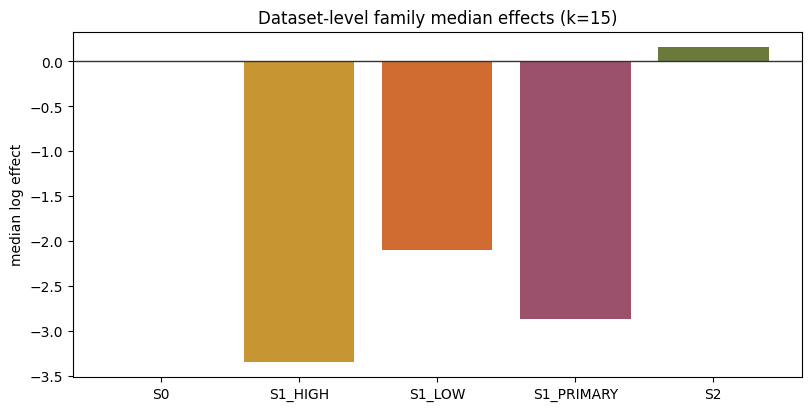

In [7]:
display(datasets)
component_view = components.pivot(index='component', columns='config', values='p95_normalized_absolute_shift')
display(component_view.round(2))
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.bar(datasets['config'], datasets['median_family_effect'], color=['#315A7D','#C79531','#D06B32','#9B506C','#697A3A'])
ax.axhline(0, color='#333333', linewidth=1)
ax.set(title='Dataset-level family median effects (k=15)', ylabel='median log effect');


## Takeaways

1. Preserve `RETIRE_OR_DEMOTE`; the consumed locked result is not retroactively passed.
2. Treat finite-draw precision as the dominant diagnosed failure mechanism.
3. Do not declare N1 adequate: raw geometry and a scientifically derived equivalence margin remain missing.
4. The next bounded development step is a balanced donor schedule plus precision-guaranteed sequential sampling, evaluated at the independent-dataset grain and with expanded geometry persistence.
5. Gate12C-1's 24/24 negative empirical pattern remains an observed but unidentified development result; no Gate12C-2 real held-out result exists.

### Limitations

k=15 is finite rather than an infinite-draw truth; the draw bootstrap is conditional on fixed cohorts; tail screens have n=15 per endpoint; persisted spectra cannot recover raw frames or principal angles; all findings here are post-locked development evidence.
